情感分类

RNN 

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
import random
import os

# 设置随机种子，保证结果可复现
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [16]:
# 1. 从本地文件加载IMDb数据集
def load_imdb_data(data_dir='aclImdb'):
    """从解压后的文件夹加载IMDb数据"""
    data = []
    # 加载训练集和测试集
    for split in ['train', 'test']:
        for sentiment in ['pos', 'neg']:
            folder = os.path.join(data_dir, split, sentiment)
            for filename in os.listdir(folder):
                if filename.endswith('.txt'):
                    with open(os.path.join(folder, filename), 'r', encoding='utf-8') as f:
                        text = f.read()
                    label = 1 if sentiment == 'pos' else 0  # 1=正面，0=负面
                    data.append((text, label, split))  # (文本, 标签, 数据集划分)
    return data

# 2. 数据预处理
class TextPreprocessor:
    def __init__(self, max_vocab_size=10000, max_seq_len=200):
        self.max_vocab_size = max_vocab_size
        self.max_seq_len = max_seq_len
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}  # 填充和未知词标记
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.vocab_size = 2  # 初始大小（包含PAD和UNK）
    
    def clean_text(self, text):
        """文本清洗：去除特殊字符、小写化等"""
        text = text.lower()
        text = re.sub(r'<.*?>', '', text)  # 去除HTML标签
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # 非字母替换为空格
        text = re.sub(r'\s+', ' ', text).strip()  # 合并多余空格
        return text
    
    def build_vocab(self, texts):
        """从训练文本构建词汇表"""
        word_counts = Counter()
        for text in texts:
            cleaned = self.clean_text(text)
            words = cleaned.split()
            word_counts.update(words)
        
        # 保留最常见的词（排除PAD和UNK）
        most_common = word_counts.most_common(self.max_vocab_size - 2)
        for word, _ in most_common:
            self.word2idx[word] = self.vocab_size
            self.idx2word[self.vocab_size] = word
            self.vocab_size += 1
        print(f"词汇表构建完成，包含 {self.vocab_size} 个词")
    
    def text_to_sequence(self, text):
        """将文本转换为索引序列"""
        cleaned = self.clean_text(text)
        words = cleaned.split()
        sequence = []
        for word in words:
            # 未知词用<UNK>标记
            sequence.append(self.word2idx.get(word, self.word2idx['<UNK>']))
        
        # 截断或填充到固定长度
        if len(sequence) > self.max_seq_len:
            sequence = sequence[:self.max_seq_len]
        else:
            sequence += [self.word2idx['<PAD>']] * (self.max_seq_len - len(sequence))
        return sequence


In [17]:
# 3. 自定义数据集
class IMDBDataset(Dataset):
    def __init__(self, data, preprocessor):
        self.data = data
        self.preprocessor = preprocessor
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        text, label, _ = self.data[idx]
        sequence = self.preprocessor.text_to_sequence(text)
        return torch.tensor(sequence, dtype=torch.long), torch.tensor(label, dtype=torch.float32)


In [18]:

# 4. 定义RNN模型
class TextRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size, num_layers=1, dropout=0.5):
        super(TextRNN, self).__init__()
        self.embedding = nn.Embedding(      # 词嵌入层
            num_embeddings=vocab_size,      # 词汇表大小
            embedding_dim=embedding_dim,    # 词嵌入维度
            padding_idx=0  # 填充标记的索引     
        )
        
        self.rnn = nn.RNN(
            input_size=embedding_dim,   # 输入维度
            hidden_size=hidden_size,    # 隐藏层大小
            num_layers=num_layers,      # RNN层数
            batch_first=True,       # 输入输出的batch维度在第一个位置
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()  # 二分类输出
    
    def forward(self, x):
        # x形状: (batch_size, seq_len)
        x_embed = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        out, _ = self.rnn(x_embed)  # (batch_size, seq_len, hidden_size)
        out = self.fc(out[:, -1, :])  # 取最后一个时间步输出
        return self.sigmoid(out)

In [19]:
# 4. 定义LSTM模型（核心修改部分）
class TextLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size, num_layers=1, dropout=0.5):
        super(TextLSTM, self).__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0  # 填充标记的索引
        )
        
        # 将RNN替换为LSTM
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,  # 多层时使用dropout
            bidirectional=False  # 单向LSTM，如需双向可设为True
        )
        
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()  # 二分类输出
    
    def forward(self, x):
        # x形状: (batch_size, seq_len)
        x_embed = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        
        # LSTM输出包含输出序列和最后时刻的隐藏状态(元组: (h_n, c_n))
        out, _ = self.lstm(x_embed)  # out形状: (batch_size, seq_len, hidden_size)
        
        # 取最后一个时间步的输出用于分类
        out = self.fc(out[:, -1, :])  # (batch_size, output_size)
        return self.sigmoid(out)


In [20]:


# 5. 训练函数
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # 验证
        model.eval()
        total_val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(device), labels.to(device).unsqueeze(1)
                outputs = model(texts)
                loss = criterion(outputs, labels)
                total_val_loss += loss.item()
                
                predicted = (outputs > 0.5).float()
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        
        avg_val_loss = total_val_loss / len(val_loader)
        val_accuracy = correct / total
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)
        
        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}')
    
    return train_losses, val_losses, val_accuracies

# 6. 测试函数
def test_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for texts, labels in test_loader:
            texts, labels = texts.to(device), labels.to(device).unsqueeze(1)
            outputs = model(texts)
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    test_acc = correct / total
    print(f'Test Accuracy: {test_acc:.4f}')
    return test_acc

# 7. 预测函数
def predict_sentiment(model, text, preprocessor, device):
    model.eval()
    sequence = preprocessor.text_to_sequence(text)
    sequence = torch.tensor(sequence, dtype=torch.long).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = model(sequence).item()
    return "正面" if prob > 0.5 else "负面", prob


In [21]:

# 8. 主函数
def main():
    # 设置设备
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'使用设备: {device}')
    
    # 加载本地数据
    print("加载IMDb数据集...")
    all_data = load_imdb_data()  # 确保aclImdb文件夹在当前目录
    
    # 划分训练集、验证集、测试集
    train_data = [d for d in all_data if d[2] == 'train']  # 原始训练集
    test_data = [d for d in all_data if d[2] == 'test']    # 原始测试集
    
    # 从训练集中拆分20%作为验证集
    random.shuffle(train_data)
    split_idx = int(0.8 * len(train_data))
    train_data, val_data = train_data[:split_idx], train_data[split_idx:]
    
    print(f"训练集: {len(train_data)}条, 验证集: {len(val_data)}条, 测试集: {len(test_data)}条")
    
    # 初始化预处理工具并构建词汇表
    preprocessor = TextPreprocessor(max_vocab_size=10000, max_seq_len=200)
    train_texts = [d[0] for d in train_data]  # 提取训练文本
    preprocessor.build_vocab(train_texts)
    
    # 创建数据集和数据加载器
    batch_size = 32
    train_dataset = IMDBDataset(train_data, preprocessor)
    val_dataset = IMDBDataset(val_data, preprocessor)
    test_dataset = IMDBDataset(test_data, preprocessor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # 初始化模型
    vocab_size = preprocessor.vocab_size
    model = TextRNN(
        vocab_size=vocab_size,
        embedding_dim=100,
        hidden_size=64,
        output_size=1,
        num_layers=2,
        dropout=0.3
    ).to(device)
    
    # 损失函数和优化器
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 训练模型
    print("\n开始训练...")
    train_losses, val_losses, val_accuracies = train_model(
        model, train_loader, val_loader, criterion, optimizer, device, epochs=10
    )
    
    # 测试模型
    print("\n开始测试...")
    test_acc = test_model(model, test_loader, device)
  
    # 可视化结果
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss curve')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Val Accuracy')
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Accuracy: {test_acc:.4f}')
    plt.title('Accuracy curve')
    plt.xlabel('Epoch')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 示例预测
    print("\n示例预测:")
    sample_texts = [
        "This movie is amazing! The acting was perfect and the story was touching.",
        "Worst film ever. I couldn't stand the bad acting and stupid plot.",
        "It's an okay movie. Not great, but not terrible either."
    ]
    for text in sample_texts:
        sentiment, prob = predict_sentiment(model, text, preprocessor, device)
        print(f"文本: {text}")
        print(f"预测: {sentiment} (概率: {prob:.4f})\n")



使用设备: cuda
加载IMDb数据集...
训练集: 20000条, 验证集: 5000条, 测试集: 25000条
词汇表构建完成，包含 10000 个词

开始训练...
Epoch [1/10]
Train Loss: 0.6954 | Val Loss: 0.6929 | Val Acc: 0.5106
Epoch [2/10]
Train Loss: 0.6888 | Val Loss: 0.6938 | Val Acc: 0.5136
Epoch [3/10]
Train Loss: 0.6823 | Val Loss: 0.6956 | Val Acc: 0.5190
Epoch [4/10]
Train Loss: 0.6683 | Val Loss: 0.7034 | Val Acc: 0.5076
Epoch [5/10]
Train Loss: 0.6499 | Val Loss: 0.7125 | Val Acc: 0.5320
Epoch [6/10]
Train Loss: 0.6247 | Val Loss: 0.7217 | Val Acc: 0.5248
Epoch [7/10]
Train Loss: 0.5982 | Val Loss: 0.7336 | Val Acc: 0.5364
Epoch [8/10]
Train Loss: 0.5797 | Val Loss: 0.7461 | Val Acc: 0.5480
Epoch [9/10]
Train Loss: 0.5631 | Val Loss: 0.7779 | Val Acc: 0.5344
Epoch [10/10]
Train Loss: 0.5532 | Val Loss: 0.7848 | Val Acc: 0.5458

开始测试...
Test Accuracy: 0.5418


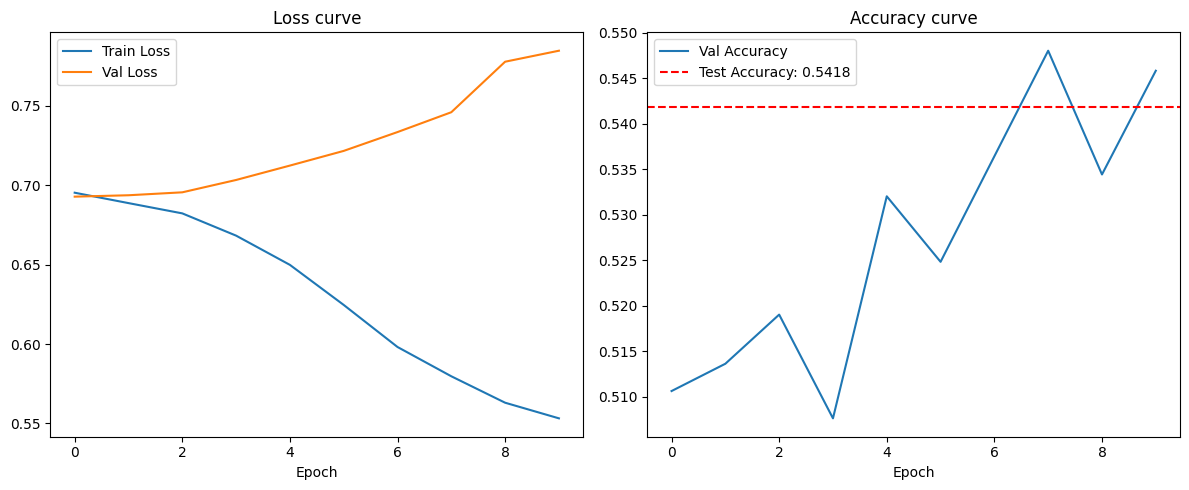


示例预测:
文本: This movie is amazing! The acting was perfect and the story was touching.
预测: 负面 (概率: 0.4662)

文本: Worst film ever. I couldn't stand the bad acting and stupid plot.
预测: 正面 (概率: 0.5982)

文本: It's an okay movie. Not great, but not terrible either.
预测: 负面 (概率: 0.4487)



In [22]:
if __name__ == "__main__":
    main()

LSTM

使用设备: cuda
加载IMDb数据集...
训练集: 20000条, 验证集: 5000条, 测试集: 25000条
词汇表构建完成，包含 10000 个词

开始训练...
Epoch [1/10]
Train Loss: 0.6906 | Val Loss: 0.6902 | Val Acc: 0.5086
Epoch [2/10]
Train Loss: 0.6764 | Val Loss: 0.6913 | Val Acc: 0.5128
Epoch [3/10]
Train Loss: 0.6688 | Val Loss: 0.6678 | Val Acc: 0.6510
Epoch [4/10]
Train Loss: 0.6651 | Val Loss: 0.6252 | Val Acc: 0.6674
Epoch [5/10]
Train Loss: 0.4997 | Val Loss: 0.4118 | Val Acc: 0.8198
Epoch [6/10]
Train Loss: 0.3397 | Val Loss: 0.3461 | Val Acc: 0.8526
Epoch [7/10]
Train Loss: 0.2714 | Val Loss: 0.3452 | Val Acc: 0.8578
Epoch [8/10]
Train Loss: 0.2163 | Val Loss: 0.3350 | Val Acc: 0.8612
Epoch [9/10]
Train Loss: 0.1710 | Val Loss: 0.3797 | Val Acc: 0.8570
Epoch [10/10]
Train Loss: 0.1382 | Val Loss: 0.4366 | Val Acc: 0.8582

开始测试...
Test Accuracy: 0.8421


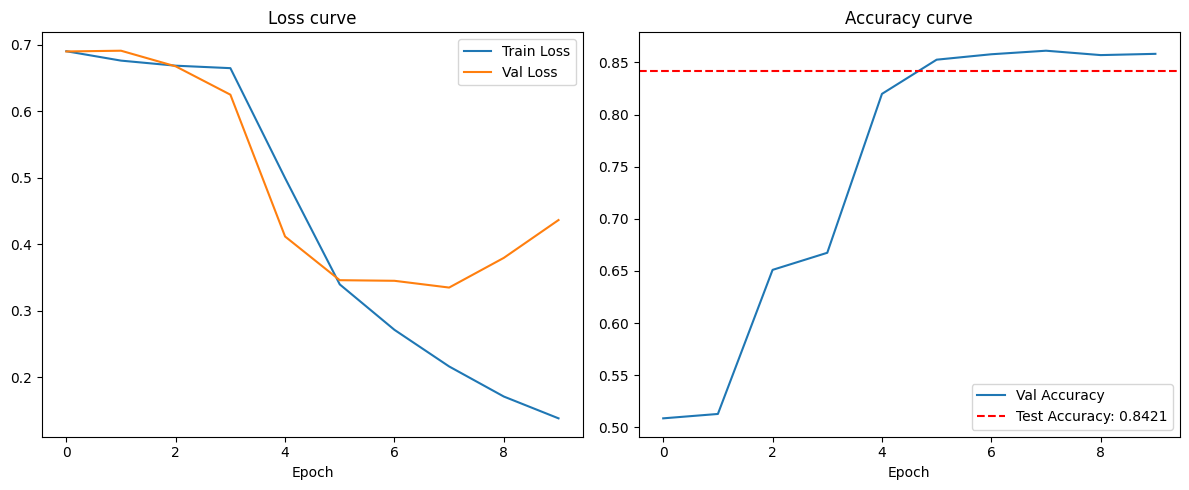


示例预测:
文本: This movie is amazing! The acting was perfect and the story was touching.
预测: 正面 (概率: 0.9902)

文本: Worst film ever. I couldn't stand the bad acting and stupid plot.
预测: 负面 (概率: 0.0092)

文本: It's an okay movie. Not great, but not terrible either.
预测: 负面 (概率: 0.0185)



In [23]:
# LSTM版本

# 8. 主函数
def main():
    # 设置设备
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'使用设备: {device}')
    
    # 加载本地数据
    print("加载IMDb数据集...")
    all_data = load_imdb_data()  # 确保aclImdb文件夹在当前目录
    
    # 划分训练集、验证集、测试集
    train_data = [d for d in all_data if d[2] == 'train']  # 原始训练集
    test_data = [d for d in all_data if d[2] == 'test']    # 原始测试集
    
    # 从训练集中拆分20%作为验证集
    random.shuffle(train_data)
    split_idx = int(0.8 * len(train_data))
    train_data, val_data = train_data[:split_idx], train_data[split_idx:]
    
    print(f"训练集: {len(train_data)}条, 验证集: {len(val_data)}条, 测试集: {len(test_data)}条")
    
    # 初始化预处理工具并构建词汇表
    preprocessor = TextPreprocessor(max_vocab_size=10000, max_seq_len=200)
    train_texts = [d[0] for d in train_data]  # 提取训练文本
    preprocessor.build_vocab(train_texts)
    
    # 创建数据集和数据加载器
    batch_size = 32
    train_dataset = IMDBDataset(train_data, preprocessor)
    val_dataset = IMDBDataset(val_data, preprocessor)
    test_dataset = IMDBDataset(test_data, preprocessor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # 初始化LSTM模型
    vocab_size = preprocessor.vocab_size
    model = TextLSTM(
        vocab_size=vocab_size,
        embedding_dim=100,
        hidden_size=64,
        output_size=1,
        num_layers=2,
        dropout=0.3
    ).to(device)
    
    # 损失函数和优化器
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 训练模型
    print("\n开始训练...")
    train_losses, val_losses, val_accuracies = train_model(
        model, train_loader, val_loader, criterion, optimizer, device, epochs=10
    )
       
    # 测试模型
    print("\n开始测试...")
    test_acc = test_model(model, test_loader, device)
    
    # 可视化结果
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss curve')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Val Accuracy')
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Accuracy: {test_acc:.4f}')
    plt.title('Accuracy curve')
    plt.xlabel('Epoch')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 示例预测
    print("\n示例预测:")
    sample_texts = [
        "This movie is amazing! The acting was perfect and the story was touching.",
        "Worst film ever. I couldn't stand the bad acting and stupid plot.",
        "It's an okay movie. Not great, but not terrible either."
    ]
    for text in sample_texts:
        sentiment, prob = predict_sentiment(model, text, preprocessor, device)
        print(f"文本: {text}")
        print(f"预测: {sentiment} (概率: {prob:.4f})\n")

if __name__ == "__main__":
    main()